In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json

In [100]:
url = "http://triton_server_p100:8000/v2/models/food_classifier_onnx/versions/1/stats"
response = requests.get(url)
json_input = json.loads(response.text)

In [101]:
json_input["model_stats"][0]["inference_stats"]["queue"]["ns"]/json_input["model_stats"][0]["inference_stats"]["queue"]["count"] / 1e6

2873.74928199

In [102]:
json_input["model_stats"][0]["inference_stats"]["compute_infer"]["ns"]/json_input["model_stats"][0]["inference_stats"]["queue"]["count"] / 1e6

34.815850579999996

In [103]:
batch_stats

[{'batch_size': 1,
  'compute_input': {'count': 3322, 'ns': 484093427},
  'compute_infer': {'count': 3322, 'ns': 24229267397},
  'compute_output': {'count': 3322, 'ns': 74449175}},
 {'batch_size': 2,
  'compute_input': {'count': 4, 'ns': 1494037},
  'compute_infer': {'count': 4, 'ns': 1389439679},
  'compute_output': {'count': 4, 'ns': 104525}},
 {'batch_size': 3,
  'compute_input': {'count': 4, 'ns': 2481392},
  'compute_infer': {'count': 4, 'ns': 1414729132},
  'compute_output': {'count': 4, 'ns': 150597}},
 {'batch_size': 5,
  'compute_input': {'count': 1, 'ns': 1027839},
  'compute_infer': {'count': 1, 'ns': 10942465564},
  'compute_output': {'count': 1, 'ns': 59519}},
 {'batch_size': 8,
  'compute_input': {'count': 431, 'ns': 670344475},
  'compute_infer': {'count': 431, 'ns': 13969627163},
  'compute_output': {'count': 431, 'ns': 12377448}}]

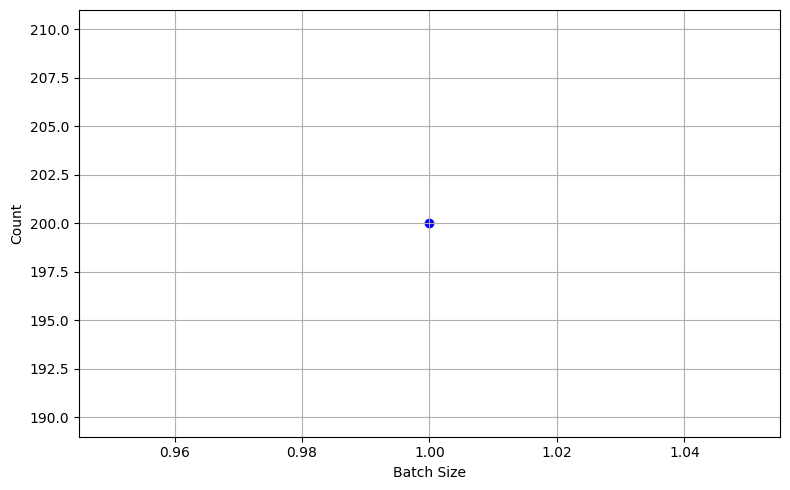

In [104]:
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_count = [
    entry["compute_infer"]["count"]
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_count, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

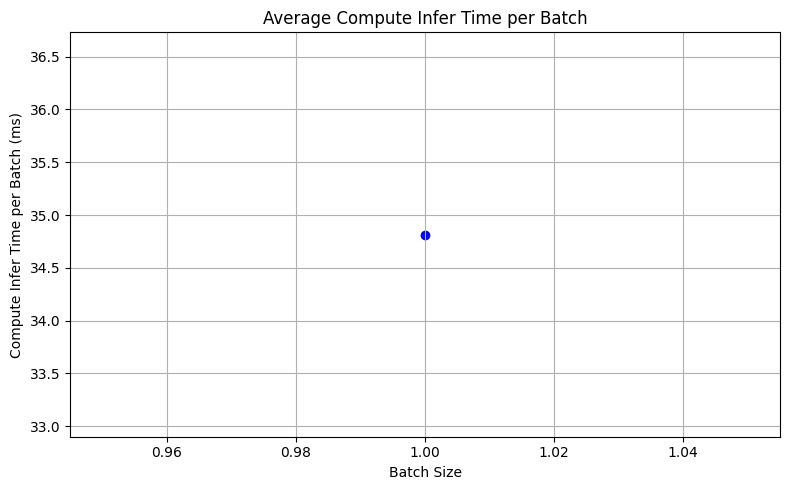

In [105]:
# Extract compute infer time per batch
batch_stats = json_input["model_stats"][0]["batch_stats"]
batch_sizes = [entry["batch_size"] for entry in batch_stats]
compute_infer_time_per_batch_ms = [
    entry["compute_infer"]["ns"] / (entry["compute_infer"]["count"] * entry["batch_size"]) / 1e6
    for entry in batch_stats
]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(batch_sizes, compute_infer_time_per_batch_ms, color='blue')
plt.xlabel("Batch Size")
plt.ylabel("Compute Infer Time per Batch (ms)")
plt.title("Average Compute Infer Time per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [106]:
import json
import numpy as np

In [117]:
with open("trace.json", 'r') as j:
     contents = json.loads(j.read())


In [118]:
min_ts = contents[0]['timestamps'][0]['ns']/1e6

In [119]:
sids = np.unique([contents[i]['id'] for i in range(len(contents))])


In [120]:
samples = []
for sidx in sids:
    s = [(contents[i]['timestamps'][0]['name'], contents[i]['timestamps'][0]['ns']/1e6 - min_ts) for i in range(len(contents)) if contents[i]['id']==sidx and 'timestamps' in contents[i].keys()]
    samples.append(s)

In [111]:
samples

[[('HTTP_RECV_START', 0.0),
  ('HTTP_RECV_END', 1.6114300042390823),
  ('REQUEST_START', 1.6769710034132004),
  ('QUEUE_START', 1.6875950023531914),
  ('INFER_RESPONSE_COMPLETE', 5.147985003888607),
  ('COMPUTE_START', 1.8925210013985634),
  ('COMPUTE_INPUT_END', 2.0426679998636246),
  ('COMPUTE_OUTPUT_START', 5.099493004381657),
  ('COMPUTE_END', 5.131328001618385),
  ('REQUEST_END', 5.1706880033016205),
  ('HTTP_SEND_START', 5.170558005571365),
  ('HTTP_SEND_END', 5.176682002842426)],
 [('HTTP_RECV_START', 9.899971999228),
  ('HTTP_RECV_END', 11.32472800463438),
  ('REQUEST_START', 11.36642200499773),
  ('QUEUE_START', 11.370209001004696),
  ('INFER_RESPONSE_COMPLETE', 14.793422006070614),
  ('COMPUTE_START', 11.39902700483799),
  ('COMPUTE_INPUT_END', 11.548978000879288),
  ('COMPUTE_OUTPUT_START', 14.766946002840996),
  ('COMPUTE_END', 14.781801000237465),
  ('REQUEST_END', 14.811108998954296),
  ('HTTP_SEND_START', 14.813486002385616),
  ('HTTP_SEND_END', 14.81904000043869)],
 [('

In [112]:
events = samples[0]

In [113]:
events

[('HTTP_RECV_START', 0.0),
 ('HTTP_RECV_END', 1.6114300042390823),
 ('REQUEST_START', 1.6769710034132004),
 ('QUEUE_START', 1.6875950023531914),
 ('INFER_RESPONSE_COMPLETE', 5.147985003888607),
 ('COMPUTE_START', 1.8925210013985634),
 ('COMPUTE_INPUT_END', 2.0426679998636246),
 ('COMPUTE_OUTPUT_START', 5.099493004381657),
 ('COMPUTE_END', 5.131328001618385),
 ('REQUEST_END', 5.1706880033016205),
 ('HTTP_SEND_START', 5.170558005571365),
 ('HTTP_SEND_END', 5.176682002842426)]

In [114]:
timestamps = [t[1] for t in events]

In [115]:
timestamps = timestamps - np.min(timestamps)

In [116]:
timestamps

array([0.        , 1.61143   , 1.676971  , 1.687595  , 5.147985  ,
       1.892521  , 2.042668  , 5.099493  , 5.131328  , 5.170688  ,
       5.17055801, 5.176682  ])